**Goal:** take a table of penguins measured four ways and collapse it into
a single 2D picture that shows the three species - without ever telling the
algorithm what a species is. Along the way: the pairwise-plot ceiling,
parallel coordinates, why you must standardize, and how to read a PCA.
Pairs with the concept note
[Seeing Many Variables at Once: Parallel Coordinates and PCA](l14_concept_many_variables_pca.qmd).

> This page is the read-only view. To run the lab, open the notebook
> (`l14_lab_penguins_pca.ipynb`) - in Colab via the badge on the concept
> page, or locally.

## Prerequisites & Setup

Run this first. One public-domain dataset, bundled with the course and
with a live download fallback:

- **Palmer Penguins:** body measurements of 344 penguins from three
  species (Adelie, Gentoo, Chinstrap) on three islands of the Palmer
  Archipelago, Antarctica. Collected by the Palmer Station Long-Term
  Ecological Research program (Gorman et al. 2014); released **CC0 /
  public domain** via the `palmerpenguins` package. The fallback URL is
  the stable seaborn-data mirror.

There is no randomness in this lab - PCA is deterministic - so no seed is
needed.

In [1]:
# Setup: run this cell first (required for Colab - it resets on open)
%pip install -q pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Palmer Penguins (Horst, Hill & Gorman 2020; CC0 public domain)
PENGUINS_LOCAL = "data/penguins.csv"
PENGUINS_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"

if not os.path.exists(PENGUINS_LOCAL):
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(PENGUINS_URL, PENGUINS_LOCAL)

features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
penguins = pd.read_csv(PENGUINS_LOCAL)
print("Shape:", penguins.shape)
print(penguins["species"].value_counts())
print()
print(penguins[["species"] + features].head(3))

Shape: (344, 7)
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

  species  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0  Adelie            39.1           18.7              181.0       3750.0
1  Adelie            39.5           17.4              186.0       3800.0
2  Adelie            40.3           18.0              195.0       3250.0


<details><summary>Expected Output</summary>

~~~text
Shape: (344, 7)
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

  species  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0  Adelie            39.1           18.7              181.0       3750.0
1  Adelie            39.5           17.4              186.0       3800.0
2  Adelie            40.3           18.0              195.0       3250.0
~~~
</details>

> **Read it:** four numeric measurements per penguin - bill length, bill
> depth, flipper length, body mass - plus the species and island labels.
> The labels are what we will *hide* from PCA and then check against: if
> the method recovers the species from the measurements alone, it found
> real structure.

## Step 1: The Pairwise-Plot Ceiling (Worked)

L08's pair plot draws every variable against every other. With four
features that is a 4x4 grid - and it works, the species already cluster:

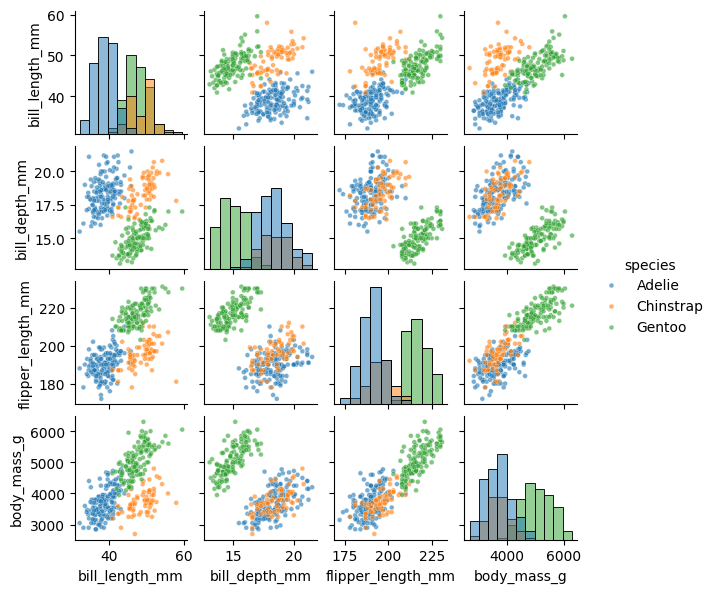

In [3]:
sns.pairplot(penguins, vars=features, hue="species",
             diag_kind="hist", height=1.5, plot_kws={"s": 12, "alpha": 0.6})
plt.show()

> **Read it:** Gentoo (one color) pulls away in almost every panel -
> they are the big penguins. But notice the cost: four features already
> mean six off-diagonal panels, and you read them one pair at a time. The
> grid grows as the *square* of the feature count.

In [4]:
clean = penguins.dropna(subset=features).reset_index(drop=True)
print("Missing values per feature:")
print(penguins[features].isna().sum())
print()
print("Rows before:", len(penguins), "-> after dropping incomplete:", len(clean))
k = len(features)
print(f"A pair plot of {k} features needs {k*(k-1)//2} panels; "
      f"10 features need {10*9//2}; 30 need {30*29//2}.")

Missing values per feature:
bill_length_mm       2
bill_depth_mm        2
flipper_length_mm    2
body_mass_g          2
dtype: int64

Rows before: 344 -> after dropping incomplete: 342
A pair plot of 4 features needs 6 panels; 10 features need 45; 30 need 435.


<details><summary>Expected Output</summary>

~~~text
Missing values per feature:
bill_length_mm       2
bill_depth_mm        2
flipper_length_mm    2
body_mass_g          2
dtype: int64

Rows before: 344 -> after dropping incomplete: 342
A pair plot of 4 features needs 6 panels; 10 features need 45; 30 need 435.
~~~
</details>

> **Read it:** two penguins are missing every measurement (likely a single
> bad capture); we drop them with `dropna` - the L09 move - leaving 342
> clean rows. And the panel count makes the lesson's whole problem
> concrete: 30 variables would need 435 panels. Nobody reads 435 panels.
> We need a way to see many variables at once.

## Step 2: Parallel Coordinates (Worked + Completion)

One alternative draws every variable on its own vertical axis and runs one
line per penguin across all of them. Because the axes have different units,
standardize first (z-score each column - L13's move, here via
`StandardScaler`) so the axes are comparable:

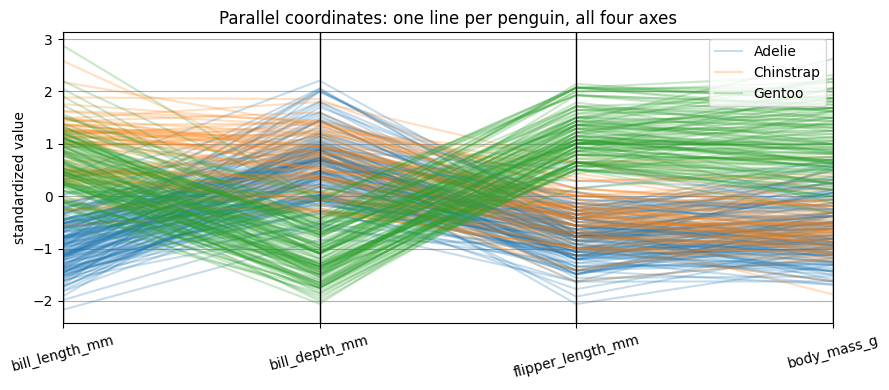

In [5]:
from pandas.plotting import parallel_coordinates

scaled = clean.copy()
scaled[features] = StandardScaler().fit_transform(clean[features])

fig, ax = plt.subplots(figsize=(9, 4))
# colors map to species in first-appearance order: Adelie, Chinstrap, Gentoo
parallel_coordinates(scaled[features + ["species"]], "species",
                     color=["#1f77b4", "#ff7f0e", "#2ca02c"], alpha=0.25, ax=ax)
ax.set_ylabel("standardized value")
ax.set_title("Parallel coordinates: one line per penguin, all four axes")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

> **Read it:** each penguin is a line crossing all four axes. Gentoo rides
> high on flipper length and body mass but *low* on bill depth - a shape
> signature you can see in one figure instead of six panels. The weakness:
> the picture depends on the axis order, and a few hundred lines already
> start to tangle. At thirty variables it becomes spaghetti.

Your turn - the per-species averages behind those bands:

In [6]:
# Uncomment and fill the ____ : group the CLEAN (unscaled) data by species
# and take the mean of the feature columns, rounded to 1 decimal.
# species_means = clean.groupby("species")[features].____().round(1)
# print(species_means)

<details><summary>Expected Output</summary>

~~~text
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie               38.8           18.3              190.0       3700.7
Chinstrap            48.8           18.4              195.8       3733.1
Gentoo               47.5           15.0              217.2       5076.0
~~~
*(Gentoo: longest flippers, heaviest, shallowest bills. Adelie and
Chinstrap are close on size but Adelie has a much shorter bill - the two
differences that PCA will line up onto two axes.)*
</details>

## Step 3: Standardize First (Worked)

Before PCA, look at what raw scales would do. The four features live on
wildly different number ranges:

In [7]:
print("Raw feature spread (std):")
print(clean[features].std().round(1))
print()
pca_raw = PCA(n_components=2).fit(clean[features])
print("UNSCALED PC1 loadings:")
for f, w in zip(features, pca_raw.components_[0]):
    print(f"  {f:<20} {w:+.3f}")
print(f"UNSCALED PC1 explains {pca_raw.explained_variance_ratio_[0]:.1%} "
      "-- but it is just the grams column")
print()
X = StandardScaler().fit_transform(clean[features])
print("After StandardScaler, every feature has std ~1.0:", np.round(X.std(axis=0), 2))

Raw feature spread (std):
bill_length_mm         5.5
bill_depth_mm          2.0
flipper_length_mm     14.1
body_mass_g          802.0
dtype: float64

UNSCALED PC1 loadings:
  bill_length_mm       +0.004
  bill_depth_mm        -0.001
  flipper_length_mm    +0.015
  body_mass_g          +1.000
UNSCALED PC1 explains 100.0% -- but it is just the grams column

After StandardScaler, every feature has std ~1.0: [1. 1. 1. 1.]


<details><summary>Expected Output</summary>

~~~text
Raw feature spread (std):
bill_length_mm         5.5
bill_depth_mm          2.0
flipper_length_mm     14.1
body_mass_g          802.0
dtype: float64

UNSCALED PC1 loadings:
  bill_length_mm       +0.004
  bill_depth_mm        -0.001
  flipper_length_mm    +0.015
  body_mass_g          +1.000
UNSCALED PC1 explains 100.0% -- but it is just the grams column

After StandardScaler, every feature has std ~1.0: [1. 1. 1. 1.]
~~~
</details>

> **Read it:** body mass varies by ~800 (grams), bill depth by ~2 (mm).
> PCA chases variance, and 800 dwarfs 2, so the unscaled PC1 is **100% body
> mass** (loading 1.000) and the bill measurements vanish - PCA has just
> renamed the grams column. `StandardScaler` rescales every feature to mean
> 0, std 1, so each gets an equal vote. **Standardizing is not optional for
> PCA; it is the difference between four features and one.** (The
> `dtype: float64` line is pandas printing the `.std()` Series footer, not
> a fifth feature.)

## Step 4: Principal Component Analysis (Worked + Completion)

Now fit PCA on the standardized matrix. Each **principal component** is a
new axis: PC1 points in the direction of greatest variation, PC2 in the
next-greatest direction perpendicular to it, and so on. The
`explained_variance_ratio_` says how much of the spread each one captures:

Explained variance ratio: [0.688 0.193 0.091 0.027]
PC1 = 68.8%, PC1+PC2 = 88.2%, PC1+PC2+PC3 = 97.3%


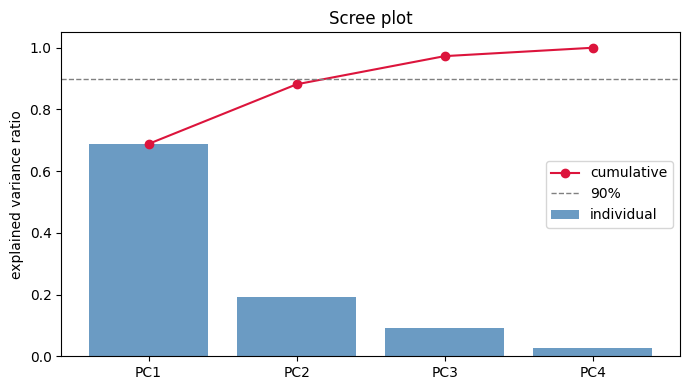

In [8]:
pca = PCA().fit(X)
evr = pca.explained_variance_ratio_
print("Explained variance ratio:", np.round(evr, 3))
print(f"PC1 = {evr[0]:.1%}, PC1+PC2 = {evr[:2].sum():.1%}, "
      f"PC1+PC2+PC3 = {evr[:3].sum():.1%}")

fig, ax = plt.subplots(figsize=(7, 4))
pcs = [f"PC{i+1}" for i in range(len(evr))]
ax.bar(pcs, evr, color="steelblue", alpha=0.8, label="individual")
ax.plot(pcs, np.cumsum(evr), color="crimson", marker="o", label="cumulative")
ax.axhline(0.9, color="gray", linestyle="--", linewidth=1, label="90%")
ax.set_ylabel("explained variance ratio")
ax.set_title("Scree plot")
ax.legend()
plt.tight_layout()
plt.show()

<details><summary>Expected Output</summary>

~~~text
Explained variance ratio: [0.688 0.193 0.091 0.027]
PC1 = 68.8%, PC1+PC2 = 88.2%, PC1+PC2+PC3 = 97.3%
~~~
</details>

> **Read it:** PC1 holds 68.8% of all the variation among penguins, PC2
> another 19.3%. Together **two new axes carry 88% of what four measured
> ones held** - so a 2D scatter of PC1 vs PC2 loses almost nothing. The
> scree plot's bars fall off a cliff after PC2 (the "elbow"): that is the
> visual cue for how many components are worth keeping.

Your turn - read the cumulative curve exactly:

In [9]:
# Uncomment and fill the ____ : np.cumsum builds the running total of evr;
# argmax of (cumulative >= 0.90) gives the FIRST index that crosses 90%
# (add 1 to turn a 0-based index into a component count).
# cum = np.cumsum(evr)
# n90 = int(np.argmax(cum >= 0.90) + 1)
# print(f"Components needed to reach 90% variance: {n90}")
# print("Cumulative variance:", np.round(cum, ____))

<details><summary>Expected Output</summary>

~~~text
Components needed to reach 90% variance: 3
Cumulative variance: [0.688 0.882 0.973 1.   ]
~~~
*(Two components clear 88% but not 90%; you need the third to cross it.
"How many to keep" is a judgment call - the elbow says two, a 90% rule
says three.)*
</details>

## Step 5: Reading the Projection (Worked)

The payoff: project every penguin onto PC1 and PC2 and plot. First, what
do the two axes *mean*? The **loadings** say how each original feature
contributes:

In [10]:
loadings = pd.DataFrame(pca.components_[:2].T, index=features, columns=["PC1", "PC2"])
print("Loadings (how each feature builds the components):")
print(loadings.round(3))

Loadings (how each feature builds the components):
                     PC1    PC2
bill_length_mm     0.455  0.597
bill_depth_mm     -0.400  0.798
flipper_length_mm  0.576  0.002
body_mass_g        0.548  0.084


<details><summary>Expected Output</summary>

~~~text
Loadings (how each feature builds the components):
                     PC1    PC2
bill_length_mm     0.455  0.597
bill_depth_mm     -0.400  0.798
flipper_length_mm  0.576  0.002
body_mass_g        0.548  0.084
~~~
</details>

> **Read it:** PC1 loads positively on flipper length, body mass, and bill
> length, negatively on bill depth - it is an **overall size** axis (big
> body, shallow bill = the Gentoo build). PC2 is almost all bill depth and
> length - a **bill shape** axis. The components are not single features;
> they are *blends*, and reading the loadings is how you name them.

Now the scatter, colored by the species PCA never saw, with the loading
arrows drawn on (a **biplot**):

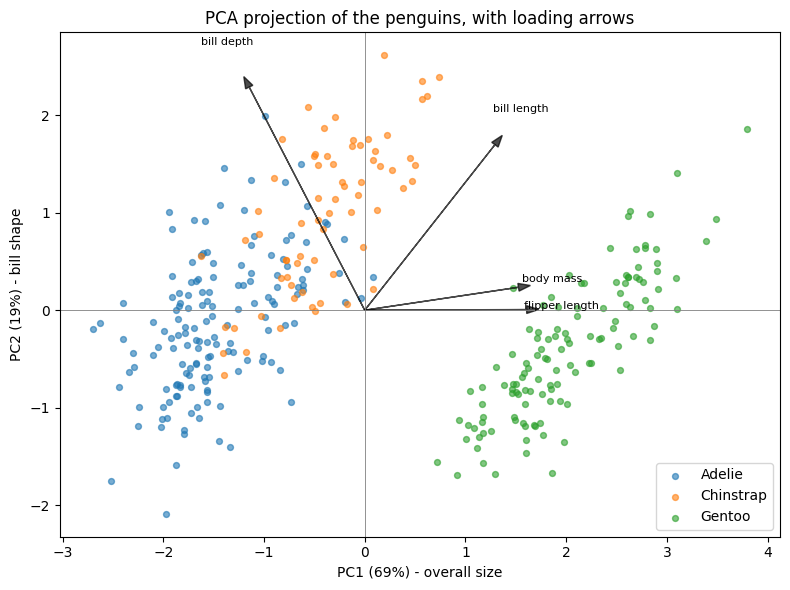

Mean PC1 by species:
species
Adelie      -1.46
Chinstrap   -0.38
Gentoo       2.01
Name: PC1, dtype: float64


In [11]:
scores = pca.transform(X)
clean["PC1"], clean["PC2"] = scores[:, 0], scores[:, 1]
palette = {"Adelie": "#1f77b4", "Chinstrap": "#ff7f0e", "Gentoo": "#2ca02c"}

fig, ax = plt.subplots(figsize=(8, 6))
for sp, color in palette.items():
    m = clean["species"] == sp
    ax.scatter(clean.loc[m, "PC1"], clean.loc[m, "PC2"], s=18, alpha=0.6,
               color=color, label=sp)
for i, f in enumerate(features):
    ax.arrow(0, 0, pca.components_[0, i]*3, pca.components_[1, i]*3,
             color="black", alpha=0.7, head_width=0.08, length_includes_head=True)
    ax.annotate(f.replace("_mm", "").replace("_g", "").replace("_", " "),
                (pca.components_[0, i]*3.4, pca.components_[1, i]*3.4),
                fontsize=8, ha="center")
ax.axhline(0, color="gray", linewidth=0.6)
ax.axvline(0, color="gray", linewidth=0.6)
ax.set_xlabel(f"PC1 ({evr[0]:.0%}) - overall size")
ax.set_ylabel(f"PC2 ({evr[1]:.0%}) - bill shape")
ax.set_title("PCA projection of the penguins, with loading arrows")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Mean PC1 by species:")
print(clean.groupby("species")["PC1"].mean().round(2))

<details><summary>Expected Output</summary>

~~~text
Mean PC1 by species:
species
Adelie      -1.46
Chinstrap   -0.38
Gentoo       2.01
Name: PC1, dtype: float64
~~~
</details>

> **Read it:** three clouds. Gentoo sits far to the right (mean PC1 +2.01 -
> big bodies); Adelie and Chinstrap overlap on size but split vertically on
> PC2 (bill shape). PCA was handed only four numbers per penguin and
> **rediscovered the species on its own** - the clusters are the biology,
> not an artifact. That is dimensionality reduction earning its keep:
> structure that took six pair-plot panels now reads in one.

One point sits alone in the far corner - the kind of extreme an analyst
should always check:

In [12]:
clean["dist"] = np.sqrt(clean["PC1"]**2 + clean["PC2"]**2)
outlier = clean.loc[clean["dist"].idxmax()]
print("Most extreme penguin in PC space:")
print(f"  species={outlier['species']}, island={outlier['island']}")
print(f"  PC=({outlier['PC1']:.2f}, {outlier['PC2']:.2f})")
print(outlier[features])

Most extreme penguin in PC space:
  species=Gentoo, island=Biscoe
  PC=(3.80, 1.86)
bill_length_mm         59.6
bill_depth_mm          17.0
flipper_length_mm     230.0
body_mass_g          6050.0
Name: 252, dtype: object


<details><summary>Expected Output</summary>

~~~text
Most extreme penguin in PC space:
  species=Gentoo, island=Biscoe
  PC=(3.80, 1.86)
bill_length_mm         59.6
bill_depth_mm          17.0
flipper_length_mm     230.0
body_mass_g          6050.0
Name: 252, dtype: object
~~~
*(A Gentoo with the longest bill in the dataset AND near-record flipper and
mass - extreme on both axes at once, which is exactly why it lands in the
corner. Not an error, just a very large penguin.)*
</details>

## Your Turn (Exercises)

### Exercise 1 - Two features instead of four

Re-run the whole PCA pipeline (standardize, fit, explained variance) using
only `flipper_length_mm` and `body_mass_g`. Print the explained-variance
ratio and compare PC1's share to the four-feature version. One sentence:
why does PC1 capture so much more here?

> **Hint:** `two = ["flipper_length_mm", "body_mass_g"]`, then the same
> `StandardScaler().fit_transform(...)` and `PCA().fit(...)` calls on
> `clean[two]`.

In [13]:
# TODO: your code here

<details><summary>Expected Output (one possible answer - match the values, not the print format)</summary>

~~~text
2-feature explained variance: [0.936 0.064]
PC1 alone now: 93.6% (vs 68.8% with all four)
~~~
*(Flipper length and body mass are strongly correlated - big penguins have
both - so a single "size" axis explains 94% of just those two. The more
correlated your features, the more PCA can compress; the four-feature case
is lower because bill shape adds a genuinely separate direction.)*
</details>

### Exercise 2 - Find the within-species oddball

The Step 5 outlier was extreme overall. Instead, find the penguin furthest
from *its own species' centroid* in PC space: group by species, get each
group's mean PC1/PC2, and compute each penguin's distance to its group
mean. Report the furthest one and its measurements. One sentence on what
makes it odd for its species.

> **Hint:** `clean.groupby("species")[["PC1","PC2"]].transform("mean")`
> gives each row its species centroid; then a distance like Step 5's.

In [14]:
# TODO: your code here

<details><summary>Expected Output (one possible answer - match the values, not the print format)</summary>

~~~text
Furthest from its species centroid: Gentoo on Biscoe
  distance 2.87 in PC space
bill_length_mm         59.6
bill_depth_mm          17.0
flipper_length_mm     230.0
body_mass_g          6050.0
~~~
*(The same large Gentoo - it is both the global outlier and the one
least typical of its own species. An outlier check that uses group
structure, not just distance from the origin.)*
</details>

### Exercise 3 - Written: when does PCA help?

You are handed a 50-column table of the 78 Puerto Rico municipios (income,
age bands, commute times, housing, dozens more). In 3-4 sentences, argue
when PCA is the right first move versus when a correlation heatmap (L08) or
a few targeted pair plots would serve better - and name one concrete risk
of jumping straight to PCA on this table.

> **Hint:** think about what PCA needs (numeric, standardized, roughly
> linear relationships) and what it costs (the new axes are blends, not
> the original quantities a policymaker asked about). Are all 50 columns
> numeric?

## Summary

| Move | Key commands | What you learned |
|------|-------------|------------------|
| See the ceiling | `sns.pairplot(...)` | Panels grow as k(k-1)/2 - 30 features = 435 panels |
| See many axes at once | `parallel_coordinates(...)` | One line per row across all features (standardize first) |
| Standardize | `StandardScaler().fit_transform(X)` | Without it, PC1 is just the biggest-unit column (body mass) |
| Reduce dimensions | `PCA().fit(X)`, `explained_variance_ratio_` | PC1+PC2 hold 88% of four features' variation |
| Choose components | scree plot, cumulative variance | Elbow says 2; the 90% rule says 3 |
| Read the projection | `transform`, loadings, scatter | PC1 = size, PC2 = bill shape; the 3 species emerge unsupervised |
| Spot outliers | distance in PC space | One giant Gentoo, extreme on both axes |

This closes **Unit V - Visualization**: spatial patterns (L12), temporal
patterns (L13), and now many-variable patterns. Next unit: recommender
systems.